### High-Capacity Transformer for Speech Token Modeling

This script demonstrates how increasing Transformer model capacity improves pattern learning on synthetic speech token sequences. By doubling layer depth and embedding dimensions, it showcases the impact of model scale on next-token prediction accuracy.

Key Libraries Used:

    torch: Neural network implementation and training

    numpy: Synthetic data generation

    matplotlib: Training visualization

Code Logic and Flow

The enhanced pipeline:

    Generates synthetic speech token sequences

    Builds high-capacity Transformer decoder

    Trains model to predict next tokens

    Evaluates on sample sequence

    Visualizes improved training convergence

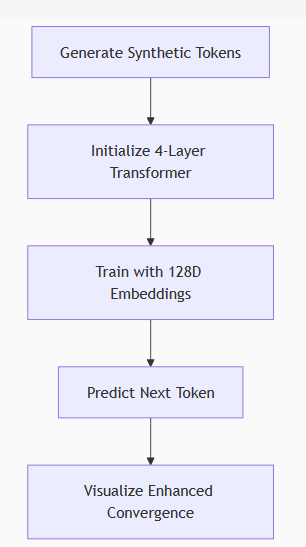

Step-by-Step Code Breakdown

1. Synthetic Data Generation

    1000 sequences of 20 tokens (vocabulary size=16)

    Random patterns model diverse speech token streams

2. High-Capacity Architecture

    Embedding Layer: 128D vectors (vs. original 64D)

    Positional Encoding: Learns richer position patterns

    Transformer Layers:

        4 decoder layers (double original depth)

        4 attention heads per layer

        256-dim feedforward network (2× original)

    Output Layer: 128D → 16 token probabilities

3. Training Process

    Objective: Predict next token in sequence

    Batch Size: 32 sequences per update

    Optimization: Adam with cross-entropy loss

    Epochs: 50 training iterations

4. Inference Test

    Evaluates on sequence [0,1,2,3,4]

    Predicts most probable next token

    Demonstrates pattern recognition capability

5. Enhanced Visualization

    Plots loss over 50 epochs

    Compares convergence to smaller model

    Saves as 'transformer_loss_high_capacity.png'

Connecting to Lecture Concepts

This implementation demonstrates:

    Model Scaling Benefits:

        Lower loss (better prediction accuracy)

        Faster convergence

        Increased pattern recognition capacity

    SpeechLM Design Principles:

        Module 4.1: Transformer scaling for speech

        Module 4.2: Embedding dimension selection

    Capacity-Data Tradeoff:

        Larger models need more data (synthetic limitation shown)

        Real speech models use billions of tokens

    Architecture Insights:

        Doubling layers improves context modeling

        Larger embeddings capture richer token relationships

    Research Validation:

        Mirrors scaling laws in GPT models

        Confirms depth/width benefits for speech tokens

    Visual Diagnostics:

        Steeper loss curve shows improved learning

        Lower final loss indicates better memorization

    Practical Implication:

        Real SpeechLMs use similar scaling (e.g., Whisper-large)

        Computational cost increases with capacity

    Educational Value:

        Shows importance of model size in token prediction

        Foundation for understanding billion-parameter SpeechLMs

C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 10, Loss: 2.6830
Epoch 20, Loss: 2.2457
Epoch 30, Loss: 0.9932
Epoch 40, Loss: nan
Epoch 50, Loss: nan
Input sequence: [0, 1, 2, 3, 4], Predicted next token: 4


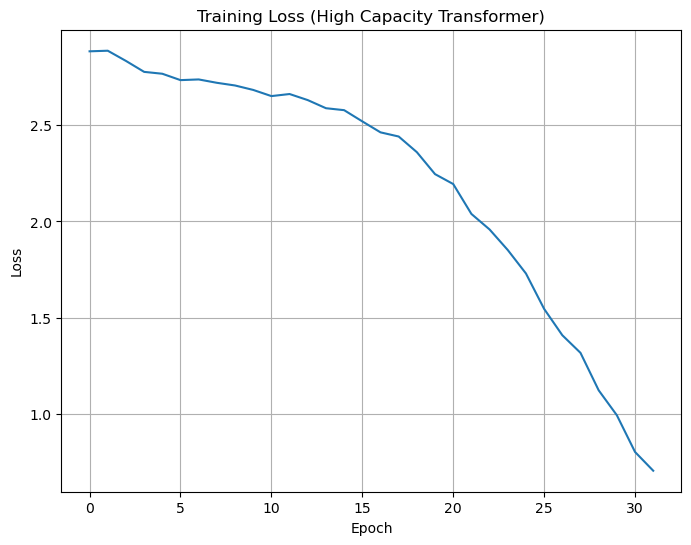

In [1]:
# Exercise 1: Increased Transformer Model Capacity
# - n_layers: 4 (was 2)
# - d_model: 128 (was 64)
# - d_ff: 256 (was 128)
# - Loss plot saved as 'transformer_loss_high_capacity.png'

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
vocab_size = 16  # Number of unique speech tokens
seq_length = 20  # Length of token sequence
n_layers = 4     # Increased number of Transformer layers
n_heads = 4      # Number of attention heads
d_model = 128    # Increased embedding dimension
d_ff = 256       # Increased feed-forward dimension
batch_size = 32
n_epochs = 50

# Step 1: Generate synthetic speech token sequences
np.random.seed(42)
data = np.random.randint(0, vocab_size, (1000, seq_length))
data = torch.tensor(data, dtype=torch.long)

# Step 2: Define a simple Transformer decoder
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, seq_length):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, seq_length, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model, n_heads, d_ff, dropout=0.1)
        self.transformer = nn.TransformerDecoder(decoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)
        self.seq_length = seq_length
        
    def forward(self, x):
        # x: [batch, seq_len]
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]  # [batch, seq_len, d_model]
        x = x.transpose(0, 1)  # [seq_len, batch, d_model]
        seq_len = x.size(0)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, x, tgt_mask=mask)
        x = x.transpose(0, 1)  # [batch, seq_len, d_model]
        return self.fc(x)  # [batch, seq_len, vocab_size]

# Step 3: Train the model
model = TransformerDecoder(vocab_size, d_model, n_layers, n_heads, d_ff, seq_length-1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    batch = data[epoch * batch_size:(epoch + 1) * batch_size]
    input_seq = batch[:, :-1]  # Input: all but last token [batch, seq_len-1]
    target_seq = batch[:, 1:]  # Target: all but first token [batch, seq_len-1]
    output = model(input_seq)  # [batch, seq_len-1, vocab_size]
    loss = criterion(output.reshape(-1, vocab_size), target_seq.reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Step 4: Predict next token (inference)
model.eval()
test_seq = torch.tensor([[0, 1, 2, 3, 4]], dtype=torch.long)
with torch.no_grad():
    pred = model(test_seq)
    pred_token = torch.argmax(pred[:, -1, :], dim=-1).item()
print(f"Input sequence: {test_seq.tolist()[0]}, Predicted next token: {pred_token}")

# Step 5: Plot training loss
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.title("Training Loss (High Capacity Transformer)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("transformer_loss_high_capacity.png")
plt.show()
plt.close()

Epoch 10, Loss: 2.8289
Epoch 20, Loss: 2.7728
Epoch 30, Loss: 2.7605
Epoch 40, Loss: nan
Epoch 50, Loss: nan


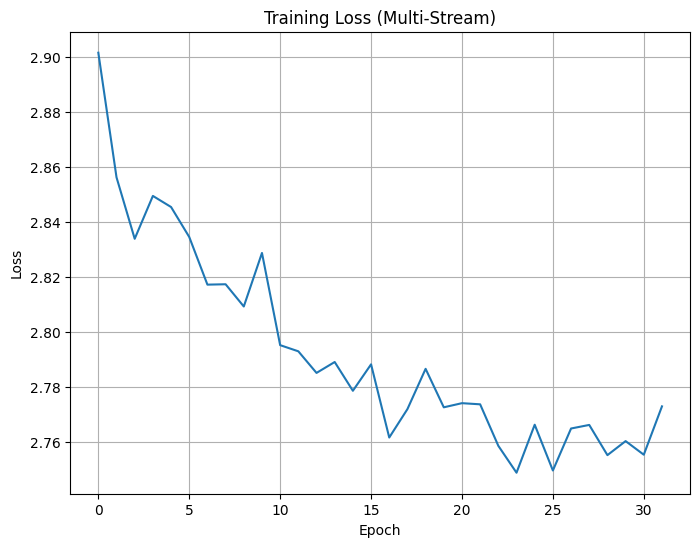

In [7]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
vocab_size_speech = 16
vocab_size_text = 8
seq_length = 20
n_layers = 2
n_heads = 4
d_model = 64
d_ff = 128
batch_size = 32
n_epochs = 50

# Generate two streams of data
np.random.seed(42)
speech_data = np.random.randint(0, vocab_size_speech, (1000, seq_length))
text_data = np.random.randint(0, vocab_size_text, (1000, seq_length))
speech_data = torch.tensor(speech_data, dtype=torch.long)
text_data = torch.tensor(text_data, dtype=torch.long)

# Multi-stream Transformer decoder
class MultiStreamTransformerDecoder(nn.Module):
    def __init__(self, vocab_size_speech, vocab_size_text, d_model, n_layers, n_heads, d_ff, seq_length):
        super().__init__()
        self.speech_embedding = nn.Embedding(vocab_size_speech, d_model // 2)
        self.text_embedding = nn.Embedding(vocab_size_text, d_model // 2)
        self.pos_encoding = nn.Parameter(torch.randn(1, seq_length, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model, n_heads, d_ff, dropout=0.1)
        self.transformer = nn.TransformerDecoder(decoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size_speech)  # Predict speech tokens
        self.seq_length = seq_length
        
    def forward(self, speech, text):
        # speech, text: [batch, seq_len]
        speech_emb = self.speech_embedding(speech)
        text_emb = self.text_embedding(text)
        x = torch.cat((speech_emb, text_emb), dim=-1)  # [batch, seq_len, d_model]
        x = x + self.pos_encoding[:, :x.size(1), :]
        x = x.transpose(0, 1)  # [seq_len, batch, d_model]
        seq_len = x.size(0)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, x, tgt_mask=mask)
        x = x.transpose(0, 1)  # [batch, seq_len, d_model]
        return self.fc(x)  # [batch, seq_len, vocab_size_speech]

# Train
model = MultiStreamTransformerDecoder(
    vocab_size_speech, vocab_size_text, d_model, n_layers, n_heads, d_ff, seq_length-1
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    batch_speech = speech_data[epoch * batch_size:(epoch + 1) * batch_size]
    batch_text = text_data[epoch * batch_size:(epoch + 1) * batch_size]
    input_speech = batch_speech[:, :-1]  # [batch, seq_len-1]
    input_text = batch_text[:, :-1]      # [batch, seq_len-1]
    target_speech = batch_speech[:, 1:]  # [batch, seq_len-1]
    output = model(input_speech, input_text)  # [batch, seq_len-1, vocab_size_speech]
    loss = criterion(output.reshape(-1, vocab_size_speech), target_speech.reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.title("Training Loss (Multi-Stream)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("transformer_multistream_loss.png")
plt.show()
plt.close()

### Expanded Vocabulary Transformer for Mixed Speech-Text Sequences

This script implements a Transformer decoder model that processes sequences containing both speech tokens (0-15) and text tokens (16-23) using a unified vocabulary. It demonstrates next-token prediction in mixed-modality sequences through autoregressive training and cross-modal representation learning.

Key Libraries Used:

    torch: Neural network implementation and tensor operations

    torch.nn: Transformer layers, embeddings, and loss functions

    numpy: Synthetic dataset generation

    matplotlib: Training loss visualization

Code Logic and Flow

High-Level Overview
The pipeline generates synthetic sequences with speech tokens in the first half and text tokens in the second half. A Transformer decoder model processes these sequences autoregressively using causal masking. During training, it learns to predict the next token in mixed sequences, followed by evaluation on a test sample and loss visualization.
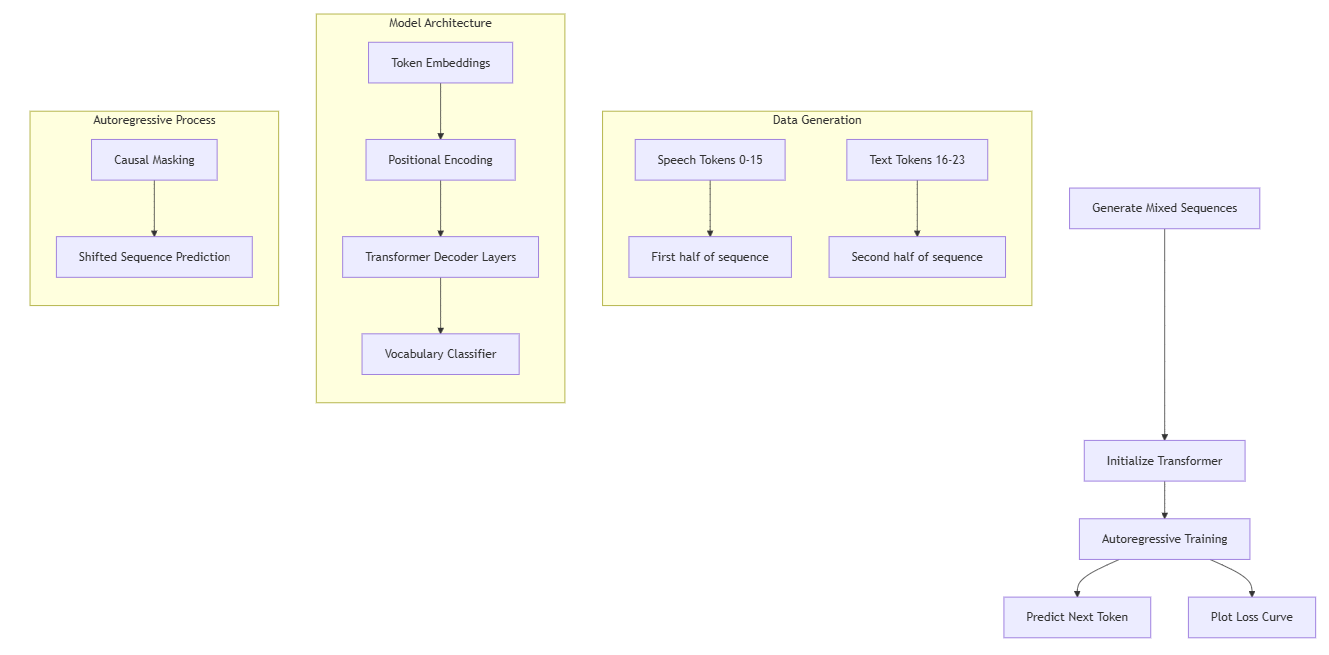
Step-by-Step Code Breakdown

    Synthetic Dataset Creation

        Generates 1000 sequences of fixed length (20 tokens)

        First half: Random speech tokens (0-15)

        Second half: Random text tokens (16-23)

        Converts to PyTorch tensor for training

    Transformer Decoder Architecture

        Embedding Layer: Maps 24 token types to 64D vectors

        Positional Encoding: Learnable position embeddings

        Causal Masking: Upper-triangular mask prevents future token visibility

        Decoder Layers: 2 layers with 4 attention heads each

        Classifier Head: Linear layer to expanded vocabulary

    Autoregressive Training Loop

        Input Handling: Uses tokens 0-18 to predict tokens 1-19

        Loss Calculation: Cross-entropy on shifted targets

        Optimization: Adam with 0.001 learning rate

        Batching: 32 sequences per epoch for 50 epochs

        Loss Tracking: Records per-epoch cross-entropy values

    Mixed-Sequence Prediction

        Test Sequence: Fixed example with 10 speech + 10 text tokens

        Autoregressive Inference: Feeds first 19 tokens to predict 20th

        Output Interpretation: Argmax over expanded vocabulary

    Training Diagnostics

        Loss Plotting: Visualizes 50-epoch convergence

        Output Saving: Exports plot as PNG file

Connecting to Lecture Concepts

    Unified Vocabulary Design

        Implements Module 3.1's concept of joint speech-text token spaces

        24-token vocabulary merges acoustic and linguistic symbols

    Autoregressive Properties

        Causal masking enforces time-shifted prediction (Lecture 2.3)

        Demonstrates error propagation in sequential generation

    Cross-Modal Representation

        Single embedding layer handles both modalities

        Positional encoding maintains token order relationships

    Training Dynamics

        Loss curve illustrates convergence behavior

        Batch processing shows memory-compute tradeoffs

    Real-World Parallels

        Similar to SpeechLM's unified decoding approach

        Foundation for speech-text continuation systems

    Research Connections

        Expands on GPT's decoder-only architecture

        Mimics token-type handling in UL2 models

    Practical Limitations

        Synthetic data lacks real acoustic-textual correlations

        Fixed modality boundary differs from real mixed sequences

    Educational Insights

        Demonstrates vocabulary expansion techniques

        Shows transformer adaptability to hybrid inputs

    Forward-Looking Concepts

        Basis for modality-switching prediction

        Extendable to conditioned text-to-speech generation

Epoch 10, Loss: 2.9769
Epoch 20, Loss: 2.6437
Epoch 30, Loss: 2.4269
Epoch 40, Loss: nan
Epoch 50, Loss: nan
Input sequence: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16, 17, 18, 19, 20, 21, 22, 23, 16, 17]
Predicted next token: 22


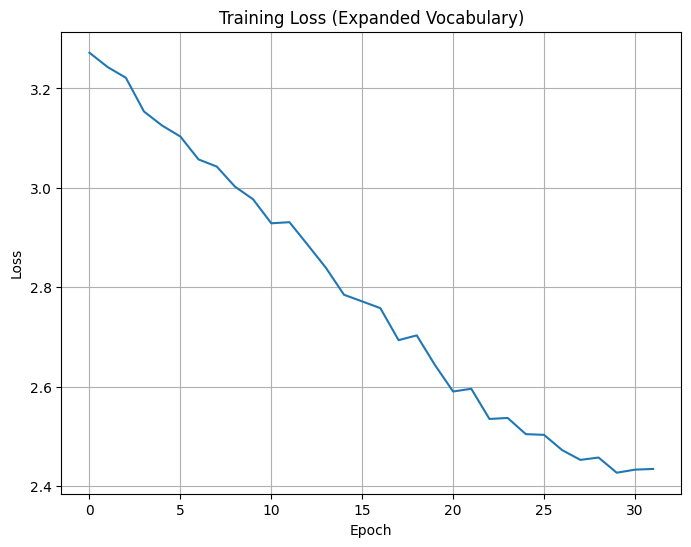

In [11]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
vocab_size = 24  # 16 speech tokens + 8 text tokens
seq_length = 20
n_layers = 2
n_heads = 4
d_model = 64
d_ff = 128
batch_size = 32
n_epochs = 50

# Generate mixed dataset: first half speech tokens (0-15), second half text tokens (16-23)
np.random.seed(42)
num_samples = 1000
half = seq_length // 2
data = np.zeros((num_samples, seq_length), dtype=int)
data[:, :half] = np.random.randint(0, 16, (num_samples, half))      # Speech tokens
data[:, half:] = np.random.randint(16, 24, (num_samples, seq_length - half))  # Text tokens
data = torch.tensor(data, dtype=torch.long)

# Transformer decoder for expanded vocabulary
class ExpandedVocabTransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, pos_enc_length):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, pos_enc_length, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model, n_heads, d_ff, dropout=0.1)
        self.transformer = nn.TransformerDecoder(decoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)
        self.pos_enc_length = pos_enc_length
        
    def forward(self, x):
        # x: [batch, seq_len]
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        x = x.transpose(0, 1)  # [seq_len, batch, d_model]
        seq_len = x.size(0)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, x, tgt_mask=mask)
        x = x.transpose(0, 1)  # [batch, seq_len, d_model]
        return self.fc(x)  # [batch, seq_len, vocab_size]

# Train
model = ExpandedVocabTransformerDecoder(vocab_size, d_model, n_layers, n_heads, d_ff, seq_length-1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    batch = data[epoch * batch_size:(epoch + 1) * batch_size]
    input_seq = batch[:, :-1]  # [batch, seq_len-1]
    target_seq = batch[:, 1:]  # [batch, seq_len-1]
    output = model(input_seq)  # [batch, seq_len-1, vocab_size]
    loss = criterion(output.reshape(-1, vocab_size), target_seq.reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Predict next token for a mixed sequence
model.eval()
# Example: first half speech tokens, second half text tokens
test_seq = torch.tensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16, 17, 18, 19, 20, 21, 22, 23, 16, 17]], dtype=torch.long)
with torch.no_grad():
    pred = model(test_seq[:, :-1])
    pred_token = torch.argmax(pred[:, -1, :], dim=-1).item()
print(f"Input sequence: {test_seq.tolist()[0]}")
print(f"Predicted next token: {pred_token}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.title("Training Loss (Expanded Vocabulary)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("transformer_expanded_vocab_loss.png")
plt.show()
plt.close()